__Installing required libraries__

In [1]:
!pip install torch torchvision numpy matplotlib scikit-learn Pillow

__Importing libraries__

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from PIL import Image
import os
import sqlite3 # the labels are in the SQLite database
import pandas as pd
import seaborn as sns

print("PyTorch version:", torch.__version__)
print("All libraries loaded")

PyTorch version: 2.10.0+cpu
All libraries loaded


__Checking the structure of the dataset and the labels__

In [3]:
# Check dataset structure
dataset_path = "micrographs" # folder containing the images
images = [f for f in os.listdir(dataset_path) if f.endswith(".png") or f.endswith(".jpg") or f.endswith(".tif")] # list of the graphical files (only png, jpg and tif returned)
print(f"Number of images: {len(images)}")
print(f"Sample filenames: {images[:5]}")

# Check labels in SQLite database
conn = sqlite3.connect("microstructures.sqlite") # opening connection to the database
cursor = conn.cursor() # enabling executing queries 

# Check available tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'") # executing SQL query to get the names of every table in the database
results = cursor.fetchall() # fetchall takes all the results from the previous query
print(f"\nTables in database: {results}") 
conn.close() # closing the database connection (always close the connection when done to free up system resources)

Number of images: 961
Sample filenames: ['micrograph1.tif', 'micrograph10.png', 'micrograph1001.tif', 'micrograph1003.tif', 'micrograph1005.tif']

Tables in database: [('user',), ('collection',), ('sample',), ('micrograph',)]


__Exploring the micrograph table to find labels__

In [4]:
conn = sqlite3.connect("microstructures.sqlite")
cursor = conn.cursor()

# Check column names in the micrograph table
cursor.execute("PRAGMA table_info(micrograph)") # query to get the information about the columns in the table "micrograph"
results = cursor.fetchall()
print("Columns in micrograph table:")
for row in results:
    print(row)

conn.close()

Columns in micrograph table:
(0, 'micrograph_id', 'INTEGER', 1, None, 1)
(1, 'path', 'VARCHAR', 0, None, 0)
(2, 'micron_bar', 'FLOAT', 0, None, 0)
(3, 'micron_bar_units', 'VARCHAR(64)', 0, None, 0)
(4, 'micron_bar_px', 'INTEGER', 0, None, 0)
(5, 'magnification', 'INTEGER', 0, None, 0)
(6, 'detector', 'VARCHAR(16)', 0, None, 0)
(7, 'sample_key', 'INTEGER', 0, None, 0)
(8, 'contributor_key', 'INTEGER', 0, None, 0)
(9, 'primary_microconstituent', 'VARCHAR(250)', 0, None, 0)


__Checking microstructure classes (labels)__

In [5]:
conn = sqlite3.connect("microstructures.sqlite")
cursor = conn.cursor()

# Getting all unique classes and count of each
cursor.execute("""
    SELECT primary_microconstituent, COUNT(*) as count 
    FROM micrograph 
    GROUP BY primary_microconstituent
    ORDER BY count DESC
""")
results = cursor.fetchall()

print("Microstructure classes:")
for row in results:
    print(f"  {row[0]}: {row[1]} images")

conn.close()

Microstructure classes:
  spheroidite: 374 images
  network: 212 images
  pearlite: 124 images
  pearlite+spheroidite: 107 images
  spheroidite+widmanstatten: 81 images
  martensite: 36 images
  pearlite+widmanstatten: 27 images


We have several __classes__:
+ spheroidite - spherical carbide particles in a ferrite matrix
+ network - carbide network at grain boundaries
+ pearlite - alternating layers of ferrite and cementite
+ martensite - hard phase formed upon rapid cooling
+ widmanstatten - characteristic lamellar structures

The number of mixed classes is low in comparison to pure classes (however, the number of files for martensite, even though it is a pure class, is also very low). To get better results and more reliable interpretation, __we will use only data for pure microstructures__.

__Loading the data__

In [6]:
# Loading only pure microstructure classes from the database
pure_classes = ["spheroidite", "network", "pearlite", "martensite"] # widmanstatten exists only with pearlite and spheroidite - not a pure class in this set

conn = sqlite3.connect("microstructures.sqlite")

# Selecting image path and label only for pure classes 
query = """
    SELECT path, primary_microconstituent 
    FROM micrograph 
    WHERE primary_microconstituent IN ('spheroidite', 'network', 'pearlite', 'martensite')
"""
df = pd.read_sql_query(query, conn) # executes an SQL query and immediately returns the result as a dataframe
conn.close()

print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df["primary_microconstituent"].value_counts().rename_axis(None)) # rename_axis(None) removes the index name (primary_microconstituent) from the displaying
df.head()

Total images: 746

Class distribution:
spheroidite    374
network        212
pearlite       124
martensite      36
Name: count, dtype: int64


,path,primary_microconstituent
0,micrograph1.tif,pearlite
1,micrograph2.tif,spheroidite
2,micrograph5.tif,pearlite
3,micrograph6.tif,spheroidite
4,micrograph8.tif,network


__Checking out some sample images__

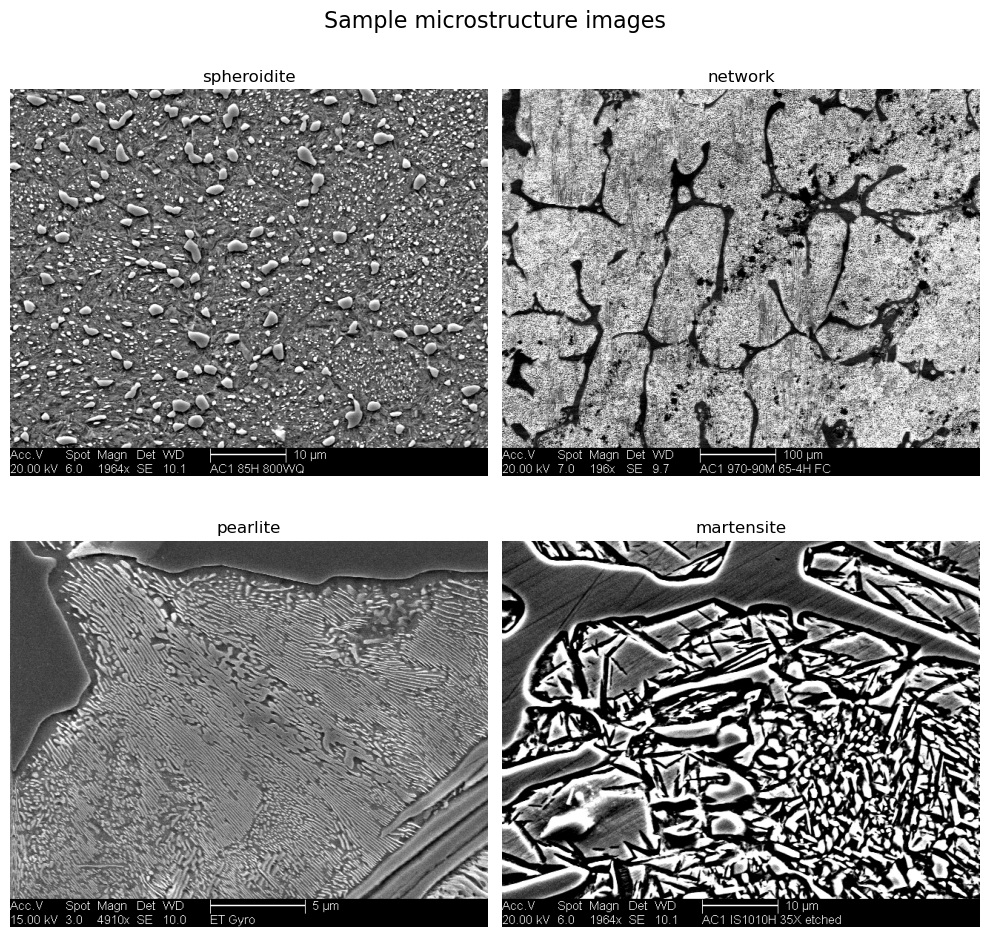

In [7]:
# Displaying sample images from each class
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Sample microstructure images", fontsize=16)

axes_flat = axes.flatten()  # converts 2x2 grid to a list of 4 elements (easier to iterate)

for i in range(len(pure_classes)):
    # from dataframe, we take only rows where class is pure_classes[i], then we take the first such row and return its file path
    class_df = df[df["primary_microconstituent"] == pure_classes[i]] # the ooutside df[...] filters the dataframe by class
    first_row = class_df.iloc[0] # iloc[0] takes the first row from the filtered dataframe
    sample_path = first_row["path"]  # getting the file path (takes only the value from the column "path" - the file name)
    
    img = Image.open(f"micrographs/{sample_path}")
    
    axes_flat[i].imshow(img, cmap="gray") # without determining colormap as gray, matplotlib creates some artificial colors for the images
    axes_flat[i].set_title(pure_classes[i])
    axes_flat[i].axis("off")

plt.tight_layout()
plt.show()

We have a few __potential problems__ to check or solve before feeding the artificial neural network (ANN):
1. different image sizes
2. large range of pixel values (0-255) - ANN will learn better with values (0 - 1) or (-1 - 1)
3. small dataset - 746 is not much

__Solutions__:
1. resizing the images
2. normalization of pixel values
3. augmentation of data - artificially expanding the dataset by adding "new" images (random image transformations (rotation, mirroring))

__Cheking the image sizes__

In [8]:
sizes = []
for path in df["path"]:
    img = Image.open(f"micrographs/{path}")
    sizes.append(img.size)  # returns (width, height)

sizes_series = pd.Series(sizes)
print("Unique image sizes:")
print(sizes_series.value_counts())

Unique image sizes:
(645, 522)    746
Name: count, dtype: int64


Problem 1. - not in our case. All the images have the same size. However, the images are quite big (645x522 pixels), so we will resize them to decrease the time of training. 

__Image preprocessing pipeline__

In [9]:
from torchvision import transforms

# Define image transformations for the training set (resize, augmentation, normalization)
transform_train = transforms.Compose([ # Compose combines several transformations into one pipeline and performs them sequentially on each image
    # Resizing the images
    transforms.Resize((128, 128)), # resizes images to 128x128
    
    # Augmentation - the microstructure of steel looks the same regardless of orientation, but model will see a "new" image - additional "information" for learning
    transforms.RandomHorizontalFlip(), # random horizontal flip
    transforms.RandomVerticalFlip(), # random vertical flip
    transforms.RandomRotation(15), # random rotation up to 15 degrees
    
    #Normalization
    
    # Converting a PIL image to a PyTorch tensor (data structure that PyTorch understands)
    transforms.ToTensor(), # converting image to PyTorch tensor (also automatically scales pixel values from 0-255 to 0-1)
    
    # Changing the scale to (-1 - 1) with 0 as a mean value - symmetrical values of pixels help with ANN learning  
    transforms.Normalize( # mean and standard deviation for grayscale (formula to recalculate: (previous value - mean) / std = new value) -> -1 for black, 1 for white
        mean=[0.5], # (0.5 - 0.5) / 0.5 = 0 
        std=[0.5]
    )
])

# Separate transform for test set (no augmentation - only resize and normalize)
transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("Transforms defined.")

Transforms defined.


__Building the Dataset in PyTorch__

We have 746 images - we can't load them all into memory at once (especially on a CPU). Dataset is a class that tells PyTorch how many images we have (len) and how to load a specific image by its number (getitem).

In [10]:
from torch.utils.data import Dataset

# We define our own class that inherits from the Dataset class from PyTorch
class MicrostructureDataset(Dataset):
    # code that is executed when we create an object of a class
    def __init__(self, dataframe, img_dir, transform=None):
        # store the dataframe (our pandas table with file names and labels), image directory and transformations (optional, default as None)
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    # checking the total number of images
    def __len__(self):
        # returns the number of rows in the dataframe
        return len(self.dataframe)

    # method that PyTorch calls when it needs a specific image
    def __getitem__(self, idx):
        # get image path and label for image at index idx
        row = self.dataframe.iloc[idx] # gets the row with idx from a dataframe
        img_path = f"{self.img_dir}/{row['path']}"
        
        # opening image and convert to grayscale
        img = Image.open(img_path).convert("L")
        
        # applying transformations if defined (if not specified, the "transform" is None and the following code is not used)
        if self.transform:
            img = self.transform(img)
        
        # getting numeric label (0, 1, 2, 3) instead of text (ANN operates on numbers, not text)
        label = pure_classes.index(row["primary_microconstituent"])
        
        return img, label

print("Dataset class defined.")

Dataset class defined.


__Dividing the dataset into training and test sets__

In [11]:
from sklearn.model_selection import train_test_split

# Split dataframe into train (80%) and test (20%) sets
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42, # seed for random number generator (we can reproduce the same splitting with the same seed)
    stratify=df["primary_microconstituent"]  # keeping class proportions in both sets
)

print(f"Training set: {len(df_train)} images")
print(f"Test set: {len(df_test)} images")
print(f"\nClass distribution in training set:")
print(df_train["primary_microconstituent"].value_counts().rename_axis(None))
print(f"\nClass distribution in test set:")
print(df_test["primary_microconstituent"].value_counts().rename_axis(None))

Training set: 596 images
Test set: 150 images

Class distribution in training set:
spheroidite    299
network        169
pearlite        99
martensite      29
Name: count, dtype: int64

Class distribution in test set:
spheroidite    75
network        43
pearlite       25
martensite      7
Name: count, dtype: int64


__Creating the Dataset and DataLoader objects__

Dataset knows how to load a single image, but the __neural network trains on batches of images simultaneously__. DataLoader automatically groups images into batches, shuffles the order, and loads images in the background during training.

In [12]:
from torch.utils.data import DataLoader

# Create dataset objects
train_dataset = MicrostructureDataset(
    dataframe=df_train,
    img_dir="micrographs",
    transform=transform_train
)

test_dataset = MicrostructureDataset(
    dataframe=df_test,
    img_dir="micrographs",
    transform=transform_test
)

# Create dataloaders
# batch_size - we aren't we training on all images at once (too much RAM/GPU and smaller batches = more weight updates = better learning)
# shuffle - shuffles the order of images before each epoch - the model does not learn the order of the data instead of its content
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # 32 images processed simultaneously in one step of learning
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # shuffle=False - the order is not important, we only evaluate the model

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 19
Test batches: 5


__Convolutional Neural Network (CNN)__

CNN is designed specifically for images - it understands that an image has a spatial structure (neighboring pixels are related to each other). 

It has several __types of layers__:
1. _Convolutional layer_ (Conv2d) - moves a small "window" (filter) across the entire image and detects patterns. The first layer detects simple patterns (edges), deeper layers are increasingly more complex (textures, structures).
2. _Activation Layer)_ (ReLU) - introduces nonlinearity (without it, the network would be just a complicated linear regression). ReLU converts negative values to 0 and leaves positive values unchanged.
3. _Pooling Layer_ (MaxPool2d) - reduces the size of the feature map while retaining the most important information. It takes a window, (e.g., 2x2) and retains only the largest value. This makes the network less sensitive to the exact position of the pattern in the image.
4. _Fully Connected Layer_ (Linear/Fully Connected) - at the end of the CNN, we flatten the results into a vector and feed it to a regular neural network, which makes the final classification decision.


__Building the CNN__

In [13]:
import torch.nn as nn

# Creating a class inheriting from nn.Module - required for any ANN in PyTorch 
class MicrostructureCNN(nn.Module):
    # defining the layers
    def __init__(self):
        super(MicrostructureCNN, self).__init__()
        
        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=1, # image comes in with 1 channel (grayscale) (for RGB - 3)
                               out_channels=32, # the layer creates 32 different filters, each detecting a different pattern (not related to batch_size)
                               kernel_size=3, # the filter has a size of 3x3 pixels
                               padding=1) # adds a 1-pixel border around the image so that the size doesn't decrease after convolution
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # stride=2 moves the window (filter) by 2 pixels (no overlap) -> new image size: 64x64 (half the original in both directions)
        
        # Second convolutional block (out_channels higher with each block to capture the icreasing complexity of patterns)                      
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # in_channels in the next block = out_channels in the previous block
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # new image size: 32x32
        
        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # new image size: 16x16
        
        # Fully connected layers
        self.flatten = nn.Flatten() # flattens a 3D feature map (128 filters × 16×16 pixels) into a single vector (32768 numbers)
        # The first fully connected layer - reduces 32768 numbers to 256 -> network "decides" which features are important
        self.fc1 = nn.Linear(128 * 16 * 16, 256) # the "flat" data (in a vector) can be now used in a linear layer
        self.relu4 = nn.ReLU()
        # Anti-overfitting technique
        self.dropout = nn.Dropout(p=0.5) # randomly "disables" 50% of the neurons at each step (forces the network to learn redundant patterns instead of remembering the training data)
        # The final layer - 4 outputs corresponding to 4 microstructure classes -> highest value = predicted class
        self.fc2 = nn.Linear(256, 4)

    # Method that defines what happens to data as it passes through the network
    def forward(self, x):
        # Pass through convolutional blocks 
        x = self.pool1(self.relu1(self.conv1(x))) # first convolution -> then ReLU -> then pooling
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        
        # Flatten and pass through fully connected layers
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create model instance
model = MicrostructureCNN() # we created the object "model" of MicrostructureCNN class 
print(model)

MicrostructureCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)


__Loss function and optimizer__

We will use _CrossEntropyLoss_ - standard loss function when we have a classification task with multiple classes.

Optimizer - algorithm which updates the network weights based on the error calculated by the loss function. We will use _Adam_ (the most popular).

In [14]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), # model.parameters() passes all the network weights to the optimizer so it knows what to update
                       lr=0.001) # lr (learning rate) - how big a step the optimizer takes when updating weights

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


__Training__

In [15]:
#  Use this block if the model was trained before

# Reinitializing model with random weights (to erase the memory of saved weights)
model = MicrostructureCNN()

# Reinitialize optimizer (must be done after reinitializing model)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
# Training loop
num_epochs = 40
best_test_acc = 0.0  # tracking the best test accuracy

# Lists to store accuracy and loss for learning curves
train_acc_history = []
test_acc_history = []
train_loss_history = []

for epoch in range(num_epochs):
    
    # TRAINING PHASE
    model.train()  # setting model to training mode (enables dropout)
    # initial values for each round of training (epoch)
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        # Step 1: clear gradients from previous batch (by default, PyTorch accumulates gradients (values needed to update weights) from each batch)
        optimizer.zero_grad() # before each new batch, we need to reset gradients to zero so they don't overlap with previous batches
        
        # Step 2: forward pass - get predictions
        outputs = model(images) # passing a batch of 32 (specified by batch_size) images through the network 
        # output is a tensor of shape [32, 4] (for each of the 32 images we get 4 values (one per class))
        
        # Step 3: calculate loss
        loss = criterion(outputs, labels) # comparing network predictions (outputs) with real labels (labels)
        
        # Step 4: backpropagation - calculate gradients
        loss.backward() # PyTorch calculates how to change each weight to reduce the error
        
        # Step 5: update weights
        optimizer.step() # optimizer uses the gradients computed by loss.backward() and updates the network weights
        
        # Track loss and accuracy
        running_loss += loss.item() # loss is a PyTorch tensor, .item() extracts a plain number from it
        # class with highest value = prediction
        predicted = torch.argmax(outputs, # argmax returns the index of the largest value - the predicted class (0, 1, 2, or 3)
                                 dim=1) # we're looking for the maximum along the class dimension of the output tensor (not along the batch dimension)
        correct += (predicted == labels).sum().item() # compares predictions with true labels, counts how many were correct
        total += labels.size(0)
    
    # Summing the losses of all batches (above) to then calculate the average loss of the epoch
    train_loss = running_loss / len(train_loader) # average loss per epoch - dividing the sum of losses by the number of batches (19)
    train_acc = correct / total * 100 # accuracy (%)
    
    # EVALUATION PHASE
    model.eval()  # setting model to evaluation mode (disables dropout)
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():  # disable gradient calculation (not needed for evaluation) - faster and saves memory
        for images, labels in test_loader:
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)
    
    test_acc = test_correct / test_total * 100

    # Saving accuracy and loss for learning curves
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    train_loss_history.append(train_loss)
    
    # Saving model if test accuracy improved
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        # saving weigths of the model to a separate file
        torch.save(model.state_dict(), "best_model.pth") # model.state_dict() saves all weights of the network as a dictionary
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}% - new best")
    else:
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc:.1f}%")

print(f"\nTraining finished. Best Test Acc: {best_test_acc:.1f}%")

Epoch 1/40 | Train Loss: 1.2351 | Train Acc: 50.7% | Test Acc: 57.3% - new best
Epoch 2/40 | Train Loss: 0.9824 | Train Acc: 59.2% | Test Acc: 60.7% - new best
Epoch 3/40 | Train Loss: 0.9638 | Train Acc: 61.7% | Test Acc: 60.7%
Epoch 4/40 | Train Loss: 0.9005 | Train Acc: 63.9% | Test Acc: 64.7% - new best
Epoch 5/40 | Train Loss: 0.8491 | Train Acc: 65.8% | Test Acc: 64.7%
Epoch 6/40 | Train Loss: 0.7967 | Train Acc: 69.1% | Test Acc: 68.7% - new best
Epoch 7/40 | Train Loss: 0.7209 | Train Acc: 74.0% | Test Acc: 70.7% - new best
Epoch 8/40 | Train Loss: 0.7187 | Train Acc: 73.8% | Test Acc: 76.0% - new best
Epoch 9/40 | Train Loss: 0.7540 | Train Acc: 70.1% | Test Acc: 68.7%
Epoch 10/40 | Train Loss: 0.6925 | Train Acc: 75.7% | Test Acc: 73.3%
Epoch 11/40 | Train Loss: 0.6020 | Train Acc: 78.7% | Test Acc: 78.7% - new best
Epoch 12/40 | Train Loss: 0.5287 | Train Acc: 83.6% | Test Acc: 80.7% - new best
Epoch 13/40 | Train Loss: 0.5765 | Train Acc: 79.5% | Test Acc: 74.0%
Epoch 14/40

__Best model evaluation__

In [17]:
# Load saved weights from file
saved_weights = torch.load("best_model.pth") # returns a dictionary with saved network weights

# Apply saved weights to the model
model.load_state_dict(saved_weights) # loading the weights into our model object (overwriting the current weights with those saved from the best result)

print("Best model loaded.")

Best model loaded.


Confusion matrix

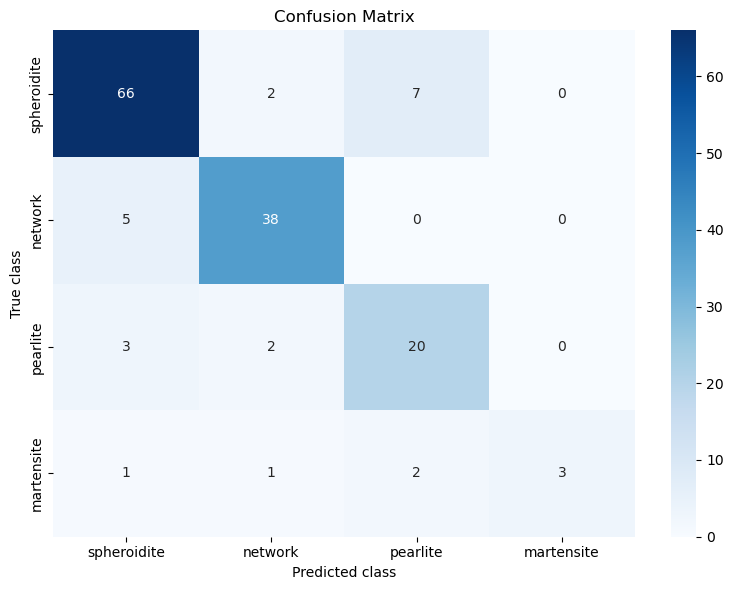

              precision    recall  f1-score   support

 spheroidite       0.88      0.88      0.88        75
     network       0.88      0.88      0.88        43
    pearlite       0.69      0.80      0.74        25
  martensite       1.00      0.43      0.60         7

    accuracy                           0.85       150
   macro avg       0.86      0.75      0.78       150
weighted avg       0.85      0.85      0.84       150



In [18]:
from sklearn.metrics import confusion_matrix, classification_report

# Collecting all predictions and true labels
model.eval()
all_predicted = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        all_predicted.extend(predicted.numpy()) # .extend adds all the elements of a list to another list
        all_labels.extend(labels.numpy()) # .numpy converts a PyTorch tensor to a NumPy array (required by sklearn)

# Confusion matrix
cm = confusion_matrix(all_labels, all_predicted) # building a confusion matrix from the collected labels and predictions

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, # shows numbers in cells
            fmt="d", # integer format (no decimal places)
            cmap="Blues", # color palette from white to blue
            xticklabels=pure_classes, yticklabels=pure_classes) # class names instead of numbers 0-3
plt.title("Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

# Detailed report
print(classification_report(all_labels, all_predicted, target_names=pure_classes)) # printing a detailed report for each class separately

__Correct predictions (diagonal):__
- spheroidite: 66/75 = 88%
- network: 38/43 = 88%
- pearlite: 20/25 = 80%
- martensite: 3/7 = 43%

__Biggest mistakes:__
- Spheroidite --> pearlite (7 images) - these two microstructures have similar visual features and the network confuses them
- Martensite --> spheroidite (1), network (1), pearlite (2) - the network isn't sure what to do with martensite, mistaking it for other classes (too little training data - 29 images)
- Network --> spheroidite (5) - relatively minor issue

__Learning curves__ - does the model learn well or lead to overfitting?

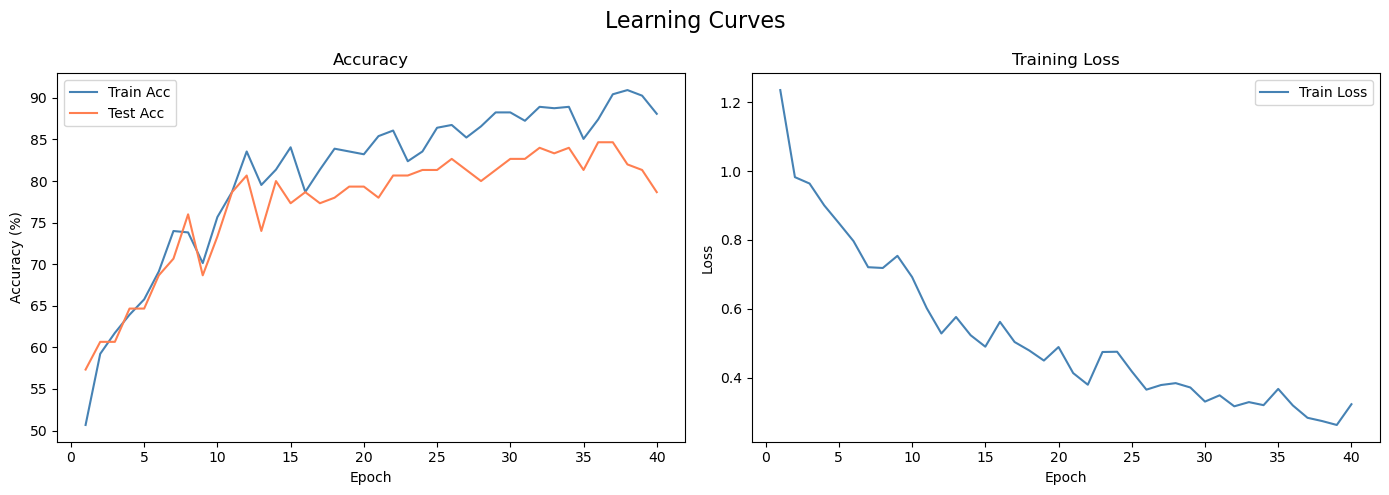

In [19]:
epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Curves", fontsize=16)

# Accuracy curves
axes[0].plot(epochs, train_acc_history, label="Train Acc", color="steelblue")
axes[0].plot(epochs, test_acc_history, label="Test Acc", color="coral")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

# Loss curve
axes[1].plot(epochs, train_loss_history, label="Train Loss", color="steelblue")
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

__Accuracy__ - Train and Test increase together, with Train slightly higher than Test. This is a healthy pattern, with no significant overfitting. The drop at the end signals that 40 epochs is a bit too much. 
__Loss__ - a systematic decrease - the network was learning the entire time.

__Logistic regression__

In [20]:
from sklearn.metrics import accuracy_score

# Flattening images to vectors for Logistic Regression
# image tensor [1, 128, 128] --> flat vector [16384] (1 x 128 x 128 = 16384)
X_train_flat = []
y_train_flat = []

# going through batches of training data (each batch contains 32 images and 32 labels)
for images, labels in train_loader:
    # going through each batch separately
    for i in range(len(images)):
        # adding a flattened image to the list
        X_train_flat.append(images[i].numpy().flatten()) # converting a PyTorch tensor to a NumPy array --> flattenning the array to the vector
        y_train_flat.append(labels[i].item()) # getting the i-th label from the batch (a PyTorch tensor with a single number) --> getting a regular number from tensor

X_test_flat = []
y_test_flat = []

for images, labels in test_loader:
    for i in range(len(images)):
        X_test_flat.append(images[i].numpy().flatten())
        y_test_flat.append(labels[i].item())

# Converting lists of vectors to numpy arrays 
X_train_flat = np.array(X_train_flat)
X_test_flat = np.array(X_test_flat)
y_train_flat = np.array(y_train_flat)
y_test_flat = np.array(y_test_flat)

print(f"Training data shape: {X_train_flat.shape}")
print(f"Test data shape: {X_test_flat.shape}")

Training data shape: (596, 16384)
Test data shape: (150, 16384)


__Training the Logistic Regression model__

In [21]:
# Creating our model (object inctance)
log_reg = LogisticRegression(
    max_iter=1000, # maximum number of iterations to converge
    random_state=42 # seed
)

# Training
log_reg.fit(X_train_flat, y_train_flat)

# Evaluating on test set
y_pred_lr = log_reg.predict(X_test_flat) # predicting the classes for the test set 
lr_accuracy = accuracy_score(y_test_flat, y_pred_lr) # % of accurate predictions

print(f"Logistic Regression Test Accuracy: {lr_accuracy*100:.1f}%")

Logistic Regression Test Accuracy: 51.3%


__CNN vs. Logistic Regression - Model comparison__

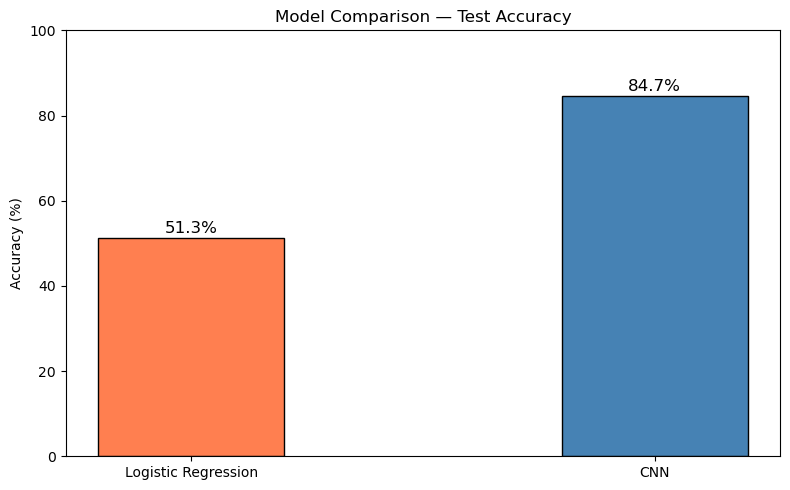

In [22]:
# Visual comparison of models
models_names = ["Logistic Regression", "CNN"]
accuracies = [lr_accuracy * 100, best_test_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, accuracies, color=["coral", "steelblue"], edgecolor="black", width=0.4)
plt.title("Model Comparison — Test Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Adding value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f"{acc:.1f}%",
             ha="center", fontsize=12)

plt.tight_layout()
plt.show()

Logistic Regression treats each pixel as an independent feature - it doesn't see that neighboring pixels create patterns, edges, or textures. An image is simply 16384 unrelated numbers.

CNN - convolutional layers detect local spatial patterns (edges --> textures --> structures). 

The difference is very  significant - 33.4 percentage points.